# Landmark Recognition - GLDv2

## CSYE7105

## Team 8

In [1]:
import os
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from time import time

import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from matplotlib.patches import Ellipse
from PIL import Image
from tqdm import tqdm

## Reading the Dataset

#### 1. Read original metadata

In [2]:
df = pd.read_csv('~/final_project/data/gldv2_metadata/train_clean.csv',dtype={'id': str})

In [3]:
df_train = pd.read_csv('~/final_project/data/gldv2_metadata/train.csv',dtype={'id': str})
df_train.shape

(4132914, 3)

#### 2. Check metadata's shapes, columns, tail(1)

In [4]:
df.shape

(81313, 2)

In [5]:
df.columns

Index(['landmark_id', 'images'], dtype='object')

In [6]:
df.tail(1)

,landmark_id,images
81312,203092,074967ced3198635 19f4a1bc4bcae084 1a5af12bccf6...


#### 3. Check whether each image referenced in the metadata actually exists in the image dataset

In [7]:
# for each row, split the images column by spaces => a list of image IDs.
df['images'] = df['images'].astype(str).str.split() 

# expand the list so that each image becomes a separate row
df = df.explode('images').reset_index(drop=True)

# change to a clearer column name: 'images' => 'image_id'
df = df.rename(columns={'images': 'image_id'})

df.head()

,landmark_id,image_id
0,1,17660ef415d37059
1,1,92b6290d571448f6
2,1,cd41bf948edc0340
3,1,fb09f1e98c6d2f70
4,7,25c9dfc7ea69838d


In [8]:
df.shape

(1580470, 2)

- construct image path

In [9]:
image_dir = Path('~/final_project/data/images_north_america/images').expanduser()

def get_image_path(img_id):
    img_id = str(img_id)
    return os.path.join(image_dir, img_id[0], img_id[1], img_id[2], f'{img_id}.jpg')

df['image_path'] = df['image_id'].apply(get_image_path)

df.head()

,landmark_id,image_id,image_path
0,1,17660ef415d37059,/home/lou.yan/final_project/data/images_north_...
1,1,92b6290d571448f6,/home/lou.yan/final_project/data/images_north_...
2,1,cd41bf948edc0340,/home/lou.yan/final_project/data/images_north_...
3,1,fb09f1e98c6d2f70,/home/lou.yan/final_project/data/images_north_...
4,7,25c9dfc7ea69838d,/home/lou.yan/final_project/data/images_north_...


In [10]:
df.to_csv('/home/lou.yan/final_project/data/my_data/train_long.csv', index=False)

- check whether each image referenced in the metadata exists in the dataset
- metadata -> images (exist or not)

In [11]:
df['exists'] = df['image_path'].apply(lambda p: os.path.exists(p))
df['exists'].value_counts()

exists
False    1465588
True      114882
Name: count, dtype: int64

- image -> metadata (referenced or not)

In [12]:
all_images = set(p.stem for p in Path(image_dir).rglob('*.jpg')) # get all images

In [13]:
meta_images = set(df['image_id'].astype(str)) # get all images in metadata
extra_images = all_images - meta_images # find the set difference between the two sets

print('All images in dataset:', len(all_images))
print('All images recorded in metadata:', len(meta_images))
print('All images not recorded in metadata:', len(extra_images))

All images in dataset: 395083
All images recorded in metadata: 1580470
All images not recorded in metadata: 280201


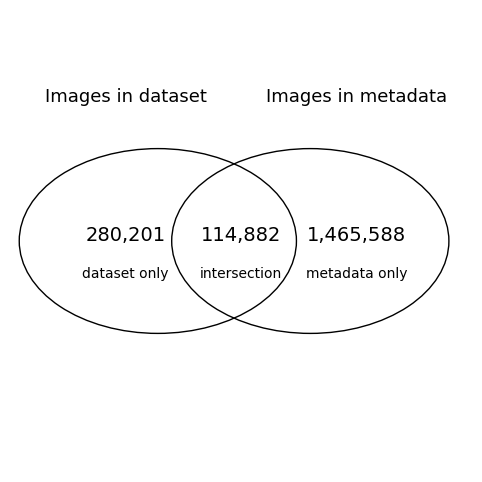

In [14]:
# plot

dataset_only = len(all_images - meta_images)        # dataset - metadata
intersection = len(all_images & meta_images)        # both
metadata_only = len(meta_images - all_images)      # metadata - dataset

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_aspect('equal')
ax.axis('off')

ellipse1 = Ellipse((0.32, 0.5), width=0.6, height=0.4, fill=False)
ellipse2 = Ellipse((0.65, 0.5), width=0.6, height=0.4, fill=False)


ax.add_patch(ellipse1)
ax.add_patch(ellipse2)


# title
ax.text(0.25, 0.8, 'Images in dataset', ha='center', fontsize=13)
ax.text(0.75, 0.8, 'Images in metadata', ha='center', fontsize=13)

# value
ax.text(0.25, 0.5, f'{dataset_only:,}', ha='center', fontsize=14)
ax.text(0.5, 0.5, f'{intersection:,}', ha='center', fontsize=14)
ax.text(0.75, 0.5, f'{metadata_only:,}', ha='center', fontsize=14)

# set
ax.text(0.25, 0.42, 'dataset only', ha='center', fontsize=10)
ax.text(0.5, 0.42, 'intersection', ha='center', fontsize=10)
ax.text(0.75, 0.42, 'metadata only', ha='center', fontsize=10)

plt.show()

- Build a new metadata (build_metadata.ipynb):

  Compute the intersection between dataset images and train metadata, copy valid images to a new directory, and save the corresponding records into 'train_filtered.cs'.

In [15]:
df = pd.read_csv('~/final_project/data/my_data/train_filtered.csv',dtype={'image_id': str,'landmark_id':str})
df.head(3)

,image_id,landmark_id,image_path,exists
0,000014b1f770f640,15430,/home/lou.yan/final_project/data/images_north_...,True
1,00001ae42cd00356,172552,/home/lou.yan/final_project/data/images_north_...,True
2,00021be1ce5ab8c3,41617,/home/lou.yan/final_project/data/images_north_...,True


In [16]:
df.shape

(114882, 4)

In [17]:
df.isna().sum()

image_id       0
landmark_id    0
image_path     0
exists         0
dtype: int64

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114882 entries, 0 to 114881
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   image_id     114882 non-null  object
 1   landmark_id  114882 non-null  object
 2   image_path   114882 non-null  object
 3   exists       114882 non-null  bool  
dtypes: bool(1), object(3)
memory usage: 2.7+ MB


In [64]:
df['landmark_id'].value_counts()

landmark_id
126637    2231
14915      754
192931     572
41808      570
80177      527
          ... 
122125       2
140893       2
192215       2
10469        2
147290       2
Name: count, Length: 7448, dtype: int64

## Explory Data Analysis

### 1. Data Scale & Basic Statistics

In [19]:
num_images = len(df)

print('Total images:', num_images)

Total images: 114882


In [20]:
num_landmarks = df['landmark_id'].nunique()

print('Number of landmark classes:', num_landmarks)

Number of landmark classes: 7448


In [21]:
# images per landmark summary
landmark_counts = df['landmark_id'].value_counts().sort_values(ascending=False)
landmark_counts.describe()

count    7448.000000
mean       15.424544
std        38.744825
min         2.000000
25%         4.000000
50%         7.000000
75%        15.000000
max      2231.000000
Name: count, dtype: float64

In [22]:
landmark_counts.head(10)

landmark_id
126637    2231
14915      754
192931     572
41808      570
80177      527
70088      409
199506     376
125425     352
33992      347
96663      343
Name: count, dtype: int64

- **Plot: How many landmarks have X images**

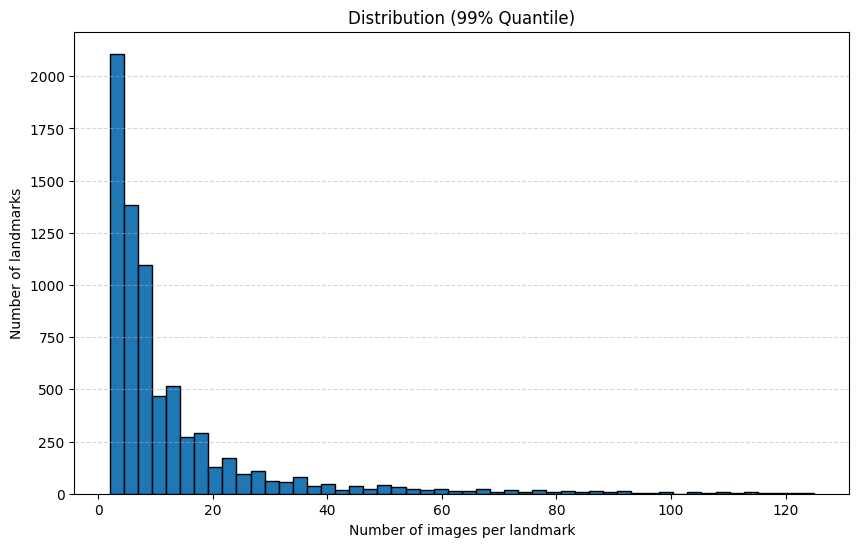

In [23]:
upper = landmark_counts.quantile(0.99)  # drop top 1%
# remove landmarks with extremely large image counts 
# to reduce the impact of outliers and better visualize the overall distribution.

filtered_counts = landmark_counts[landmark_counts <= upper]

plt.figure(figsize=(10, 6))
plt.hist(filtered_counts, bins=50, edgecolor='black')

plt.xlabel('Number of images per landmark')
plt.ylabel('Number of landmarks')
plt.title('Distribution (99% Quantile)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

- Left: Over 2,000 landmarks have only 1–5 images
- Middle: A smaller number of landmarks have around 10–30 images
- Right tail: Only a few landmarks have a large number of images

**Conclusion:** The distribution is highly imbalanced. It's a typical Long-tail distribution: 
- most landmarks have only a few images, 
- while only a small number of landmarks have many images.

- **Plot: Top 20 Landmarks with Most Image**

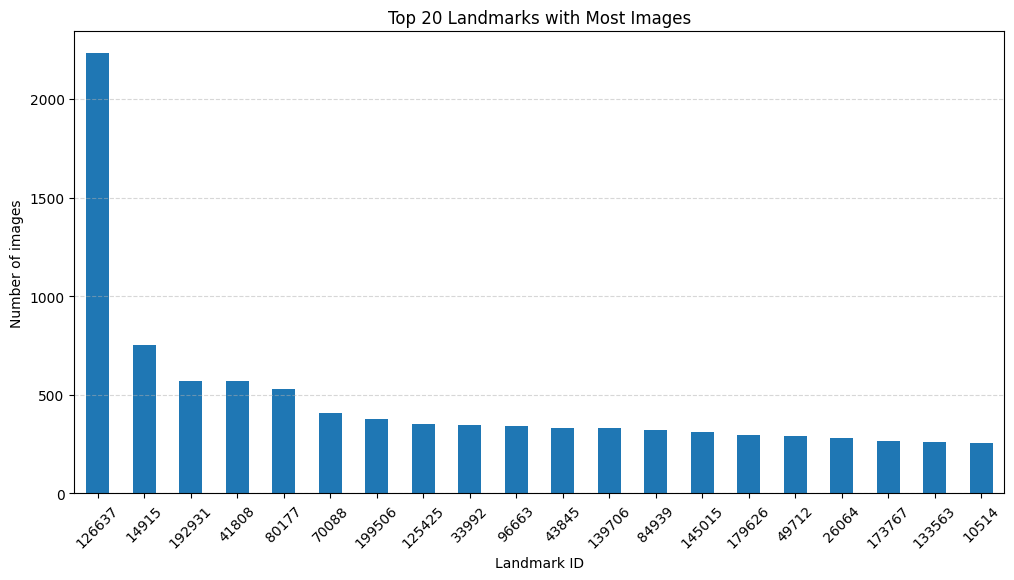

In [24]:
top10 = landmark_counts.head(20)

plt.figure(figsize=(12, 6))
top10.plot(kind='bar')
plt.xlabel('Landmark ID')
plt.ylabel('Number of images')
plt.title('Top 20 Landmarks with Most Images')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

- The top landmark (ID 126637) has significantly more images (~2200+) than others
- There is a sharp drop after the first few classes

Implications for training:
-  model may be biased toward frequent classes
- Performance on rare landmarks may be poor
- This indicates a class imbalance problem

Considerations:
- Use class weighting or balanced sampling
- Pay attention to performance on minority classes

**Conclusion:** A few landmark classes dominate the dataset, which may lead to biased model training.

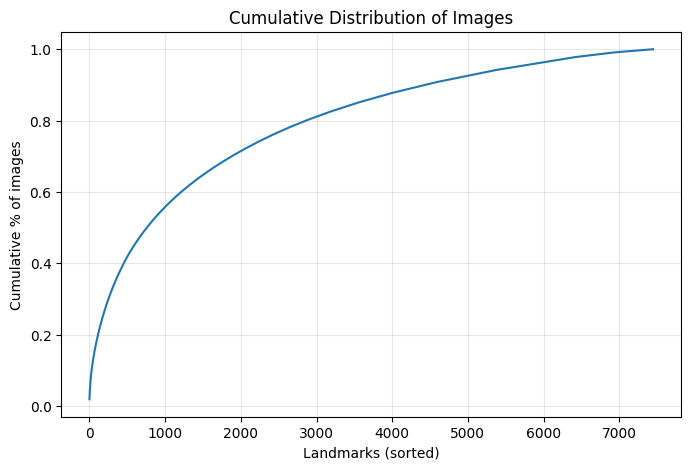

In [79]:
sorted_counts = counts.sort_values(ascending=False)
cumulative = sorted_counts.cumsum() / sorted_counts.sum()

plt.figure(figsize=(8,5))
plt.plot(cumulative.values)

plt.title('Cumulative Distribution of Images')
plt.xlabel('Landmarks (sorted)')
plt.ylabel('Cumulative % of images')

plt.grid(alpha=0.3)
plt.show()


- The curve rises quickly at the beginning and then flattens out
=>This means that most landmarks contribute only a small number of images
- A classification model will be dominated by head classes
- Tail classes are underrepresented and hard to learn

**Conclusion:**
- A small fraction of landmarks contributes most of the images
- The dataset shows a strong long-tail distribution

**Therefore:**
- Metric learning is needed

### 2. Image Layer EDA


- Image Size Distribution

In [65]:
img_dir = Path('~/final_project/data/my_data/images').expanduser()

widths = []
heights = []
aspect_ratios = []
blur_scores = []
brightness_scores = []
image_ids = []
landmark_ids = []

# build mapping: image_id -> landmark_id
id_to_landmark = dict(zip(df['image_id'], df['landmark_id']))

image_paths = list(img_dir.glob('**/*.jpg'))

for path in tqdm(image_paths):
    try:
        image_id = path.stem
        landmark_id = id_to_landmark.get(image_id, None)
        
        # size
        with Image.open(path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
            aspect_ratios.append(w / h)
            
        # blur, brightness
        img = cv2.imread(str(path))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        blur = cv2.Laplacian(gray, cv2.CV_64F).var()
        blur_scores.append(blur)

        brightness = np.mean(gray)
        brightness_scores.append(brightness)

        # ids
        image_ids.append(image_id)
        landmark_ids.append(landmark_id)
        
    except:
        continue

df_img = pd.DataFrame({
    'image_id': image_ids,
    'landmark_id': landmark_ids,
    'width': widths,
    'height': heights,
    'aspect_ratio': aspect_ratios,
    'blur': blur_scores,
    'brightness':brightness_scores
})


100%|██████████| 114882/114882 [15:24<00:00, 124.22it/s]


In [66]:
df_img.head()

,image_id,landmark_id,width,height,aspect_ratio,blur,brightness
0,000014b1f770f640,15430,800,600,1.333333,3213.215067,136.928042
1,00001ae42cd00356,172552,800,600,1.333333,439.379572,130.029610
2,00021be1ce5ab8c3,41617,800,535,1.495327,2144.960324,131.228519
3,00022c4a6a1bb331,31390,800,600,1.333333,320.615028,138.842835
4,000231b41e462da8,99138,600,800,0.750000,870.337602,88.487165


In [67]:
df_img['landmark_id'].nunique()

7448

In [68]:
df_img.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114882 entries, 0 to 114881
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   image_id      114882 non-null  object 
 1   landmark_id   114882 non-null  object 
 2   width         114882 non-null  int64  
 3   height        114882 non-null  int64  
 4   aspect_ratio  114882 non-null  float64
 5   blur          114882 non-null  float64
 6   brightness    114882 non-null  float64
dtypes: float64(3), int64(2), object(2)
memory usage: 6.1+ MB


- Plot: Histogram（width / height）

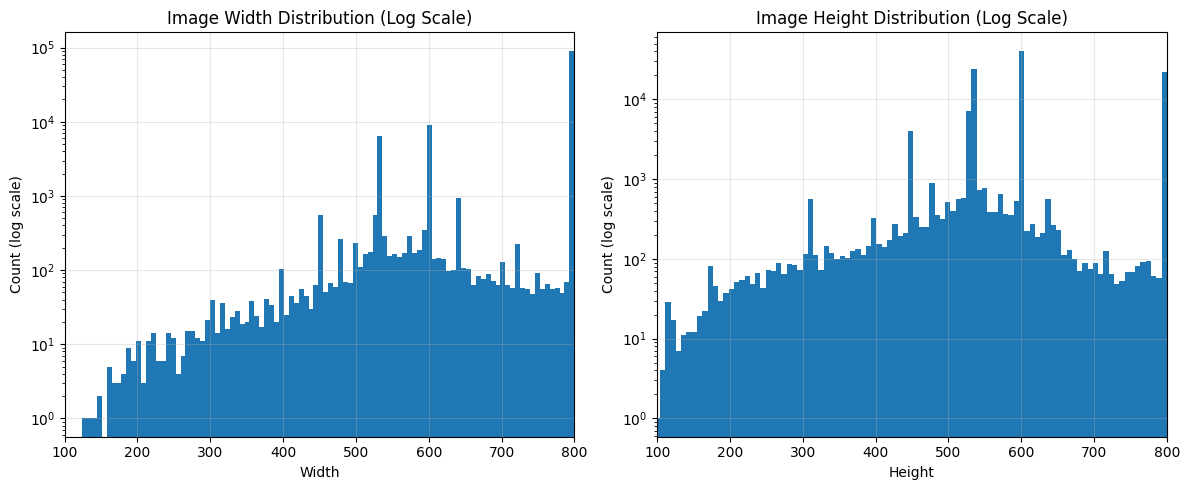

In [28]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(df_img['width'], bins=100, log=True)
plt.title('Image Width Distribution (Log Scale)')
plt.xlabel('Width')
plt.ylabel('Count (log scale)')
plt.xlim(100, 800)
plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.hist(df_img['height'], bins=100, log=True)
plt.title('Image Height Distribution (Log Scale)')
plt.xlabel('Height')
plt.ylabel('Count (log scale)')
plt.xlim(100, 800)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

- Most data are concentrated in a central range,
- with extensions on both sides,
- and low-frequency values remain visible.

 => long-tail distribution (without log scaling, these low-frequency extreme values would not be clearly visible)

- Both width and height follow similar distribution patterns

**Conclusion:** 
- The variation in image sizes makes it unsuitable to directly input images into a deep learning model
- Therefore, resizing is necessary to ensure consistent input dimensions
- We will resize all images to a fixed size (e.g., 224 × 224) for model training
- Fixed-size inputs are required for efficient batch processing and GPU-based training

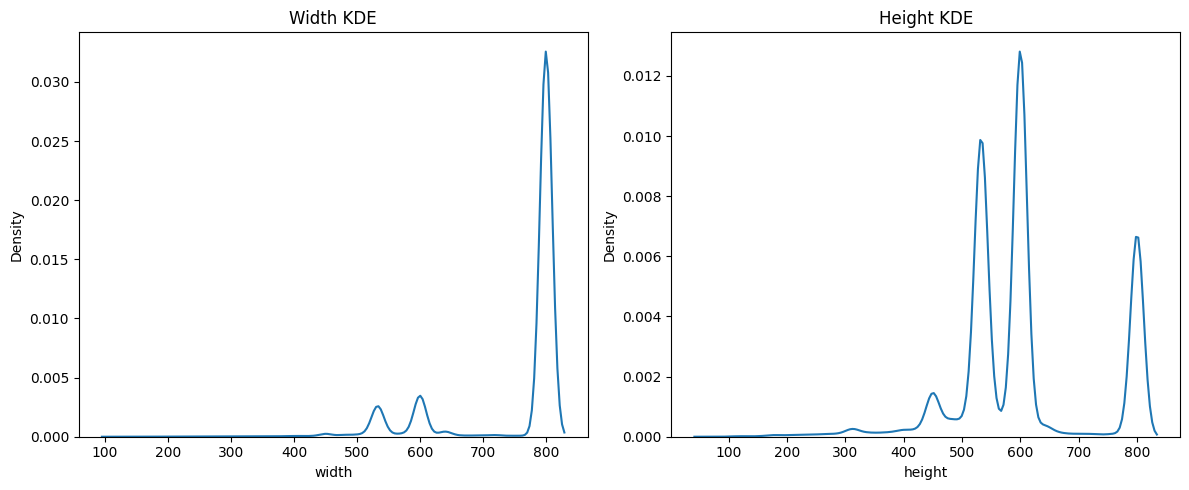

In [29]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.kdeplot(df_img['width'])
plt.title('Width KDE')

plt.subplot(1,2,2)
sns.kdeplot(df_img['height'])
plt.title('Height KDE')

plt.tight_layout()
plt.show()

- The KDE curves show a strong peak around 800 pixels => a common standardized image size
- There is also a broader concentration around 500–600 pixels
- the dataset contains diverse image resolutions

- Plot: Histogram（aspect ratio）

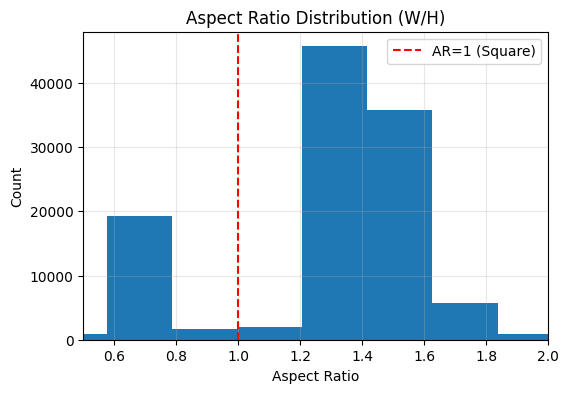

In [31]:
plt.figure(figsize=(6,4))

plt.hist(df_img['aspect_ratio'], bins=50)
plt.title('Aspect Ratio Distribution (W/H)')
plt.xlabel('Aspect Ratio')
plt.ylabel('Count')

plt.xlim(0.5, 2)

plt.axvline(x=1, linestyle='--', color='red', label='AR=1 (Square)')
plt.legend()

plt.grid(alpha=0.3)
plt.show()

- Most images have aspect ratios between 1.2 and 1.5 => indicating that many images are slightly wider than they are tall
- A small number of images with aspect ratios close to 1 (near-square images)
- There is also a noticeable number of images falls below 1  => representing portrait (tall) images

**Conclusion:** 
- Direct resizing to a fixed size (e.g., 224 × 224) may introduce distortion for non-square images
- However, since most images are close to square or moderately wide, resizing is still a reasonable approach

- Plot: blur detection (Laplacian Variance)

In [32]:
print(len(blur_scores))
print(len(brightness_scores))

114882
114882


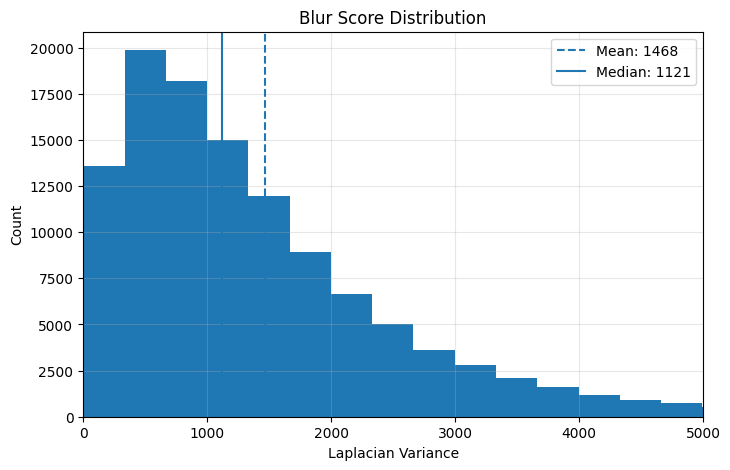

In [40]:
plt.figure(figsize=(8,5))

plt.hist(df_img['blur'], bins=80)

# focus range
plt.xlim(0, 5000)

# stats
mean_blur = df_img['blur'].mean()
median_blur = df_img['blur'].median()

plt.axvline(mean_blur, linestyle='--', label=f"Mean: {mean_blur:.0f}")
plt.axvline(median_blur, linestyle='-', label=f"Median: {median_blur:.0f}")

plt.title('Blur Score Distribution')
plt.xlabel('Laplacian Variance')
plt.ylabel('Count')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

**Laplacian Variance:** 
- Measures the intensity of image edges and details,
used to assess sharpness.
- higher blur score => sharper the image
- very small (close to 0) => very blurry

Blur Score  ~  	Quality Assessment
- < 100	        very blurry
- 100 – 300	    somewhat blurry
- 300 – 1000	average
- 1000 – 3000	clear
- 3000+         very clear


**Observation:**
- The distribution is highly right-skewed with a long tail
- Most images are concentrated in the score range (0–3000)
- A small number of images have very high sharpness

Note: To better visualize the distribution, we limit the x-axis range and include mean/median indicators

In [41]:
df_img['blur'].quantile([0.01, 0.05, 0.1])

0.01     65.096804
0.05    184.500796
0.10    297.132652
Name: blur, dtype: float64

- 1% of images have blur scores ≤ 65 (extremely blurry)
- 5% of images have blur scores ≤ 184 (very blurry)
- 10% of images have blur scores ≤ 297 (moderately blurry)

- Plot: Blur Distribution with Quantile Thresholds

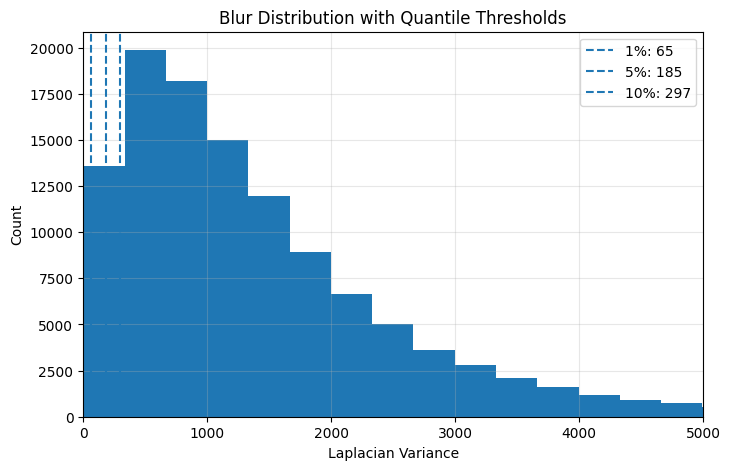

In [43]:
plt.figure(figsize=(8,5))

plt.hist(df_img['blur'], bins=80)

# calculate quantiles
q01 = df_img['blur'].quantile(0.01)
q05 = df_img['blur'].quantile(0.05)
q10 = df_img['blur'].quantile(0.10)

# plot line
plt.axvline(q01, linestyle='--', label=f'1%: {q01:.0f}')
plt.axvline(q05, linestyle='--', label=f'5%: {q05:.0f}')
plt.axvline(q10, linestyle='--', label=f'10%: {q10:.0f}')

plt.xlim(0, 5000)
plt.title('Blur Distribution with Quantile Thresholds')
plt.xlabel('Laplacian Variance')
plt.ylabel('Count')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

- A large number of images fall below blur ≈ 1000
- Low-blur images may introduce noise into the training process
- Considering to remove the lowest 5% of images can improve overall data quality

- Plot: Number of Images Below Blur Thresholds

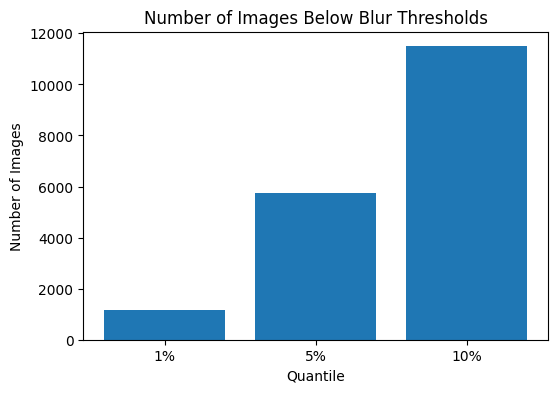

In [44]:
quantiles = df_img['blur'].quantile([0.01, 0.05, 0.1])

counts = [(df_img['blur'] <= v).sum() for v in quantiles]

plt.figure(figsize=(6,4))
plt.bar(['1%', '5%', '10%'], counts)

plt.title('Number of Images Below Blur Thresholds')
plt.xlabel('Quantile')
plt.ylabel('Number of Images')

plt.show()

- Around 1,100 images fall below the 1% threshold (≈ 1,100 images)
- Around 5,800 images fall below the 5% threshold (≈ 5,800 images)
- Around 11,500 images fall below the 10% threshold (≈ 11,500 images)

In [52]:
# define a display function
def show_images(df, title, n=5):
    plt.figure(figsize=(15,3))
    
    for i, (_, row) in enumerate(df.iterrows()):
        img_id = row['image_id']
        path = get_image_path(img_id)
        
        img = cv2.imread(str(path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(f"blur={row['blur']:.0f}")
        plt.axis('off')
    
    plt.suptitle(title)
    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.show()

- Plot: display 5 images with the lowest blur

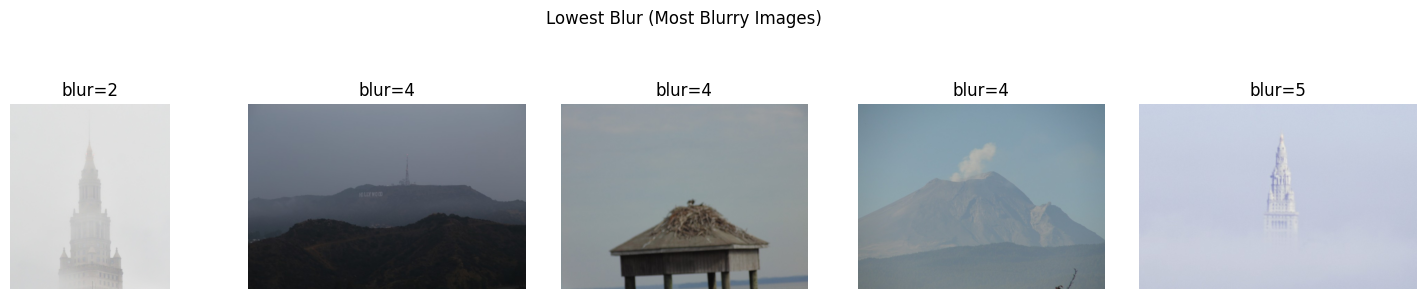

In [53]:
lowest = df_img.nsmallest(5, 'blur')
show_images(lowest, 'Lowest Blur (Most Blurry Images)')

- Plot: display 5 images with the median blur

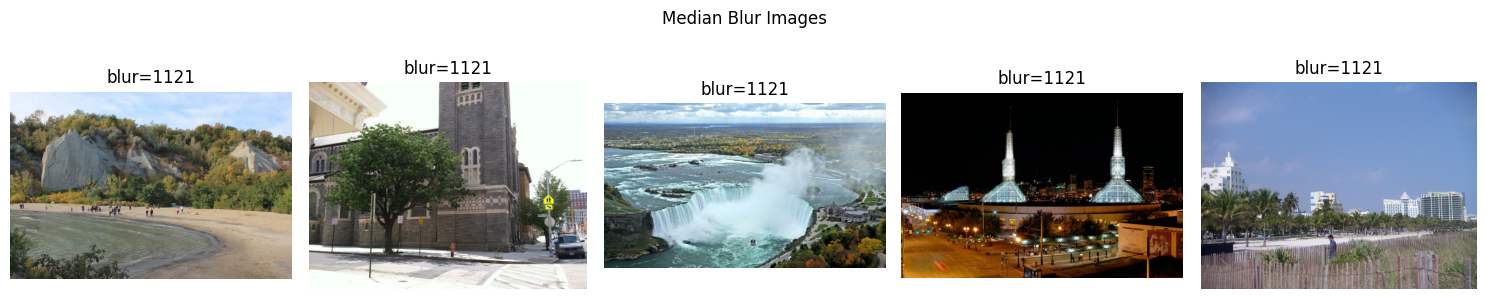

In [54]:
median_blur = df_img['blur'].median()

middle = df_img.iloc[(df_img['blur'] - median_blur).abs().argsort()[:5]]
show_images(middle, 'Median Blur Images')

- Plot: display 5 images with the highest blur

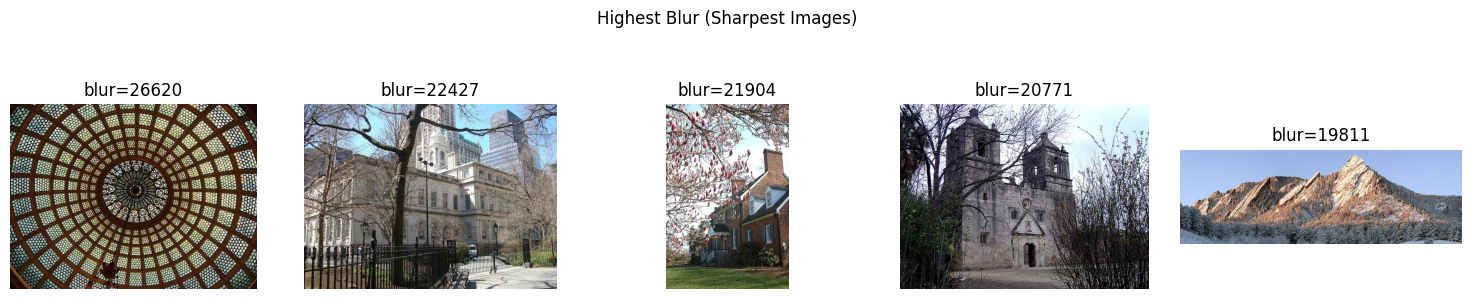

In [55]:
highest = df_img.nlargest(5, 'blur')
show_images(highest, 'Highest Blur (Sharpest Images)')

- Plot: Brightness distribution

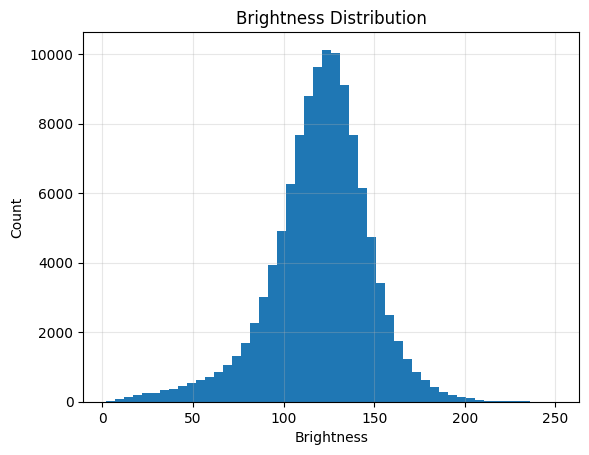

In [36]:
plt.hist(df_img['brightness'], bins=50)
plt.title('Brightness Distribution')
plt.xlabel('Brightness')
plt.ylabel('Count')
plt.grid(alpha=0.3)
plt.show()

- Bell-shaped distribution: Most images are concentrated between 100–140; The peak is around 120
- Left side (<50): Very dark images
- Right side (>180): Very bright / overexposed images

Conclusion:

- Overall exposure is generally normal
- There are a small number of images with abnormal lighting conditions

In [80]:
df_img[['brightness', 'blur']].corr()

,brightness,blur
brightness,1.000000,-0.007782
blur,-0.007782,1.000000


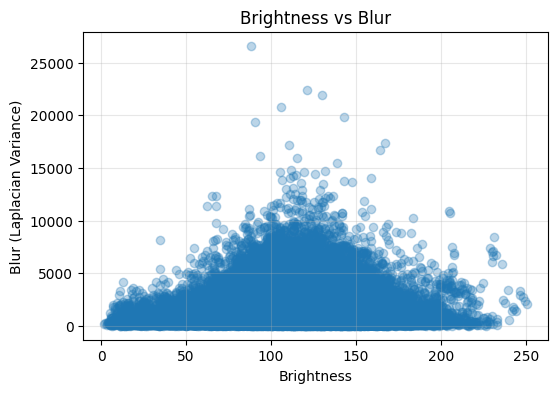

In [74]:
plt.figure(figsize=(6,4))

plt.scatter(df_img['brightness'], df_img['blur'], alpha=0.3)

plt.xlabel('Brightness')
plt.ylabel('Blur (Laplacian Variance)')
plt.title('Brightness vs Blur')

plt.grid(alpha=0.3)
plt.show()

- Brightness ≈ 80–150
- Blur has the widest distribution range
- There are many high blur values (sharp images)
- The points form a “cloud-like” pattern with no clear linear trend
- Brightness and Blur show little to no strong correlation